# 🏠 House Price Prediction
**Internship Project — Week 1**  
**Dataset:** Housing Prices Dataset (Kaggle — yasserh)  
**Tools:** Python · Pandas · Scikit-learn · Matplotlib · Seaborn

In [1]:
# ── Import all required libraries ────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

# Plot styling
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


---
## Task 1 — Data Loading & Exploration

In [2]:
# Load the dataset
df = pd.read_csv('Housing.csv')

print('✅ Dataset loaded successfully!')
print(f'Shape: {df.shape[0]} rows × {df.shape[1]} columns')

✅ Dataset loaded successfully!
Shape: 545 rows × 13 columns


In [3]:
# Display the first 10 rows
print('📋 First 10 rows of the dataset:')
df.head(10)

📋 First 10 rows of the dataset:


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,8565081,8920,2,3,3,yes,no,yes,yes,no,0,yes,unfurnished
1,3799658,2510,3,2,2,yes,yes,no,yes,no,1,no,furnished
2,6110238,7040,4,1,2,yes,no,no,no,yes,2,no,furnished
3,10558578,15068,2,2,2,yes,no,no,no,no,3,no,unfurnished
4,5894310,6841,2,2,2,yes,no,yes,no,no,3,no,unfurnished
5,10245189,13614,6,2,1,yes,yes,no,yes,no,3,no,semi-furnished
6,9259639,12934,4,2,2,yes,no,no,no,no,1,no,semi-furnished
7,5138798,7384,1,3,2,no,no,no,no,no,1,no,furnished
8,7042075,7915,3,2,4,yes,no,no,no,no,2,no,furnished
9,3784330,2116,3,2,2,no,no,yes,no,yes,3,no,semi-furnished


In [4]:
# Rows and columns
print(f'📐 Number of rows    : {df.shape[0]}')
print(f'📐 Number of columns : {df.shape[1]}')
print()

# Target vs Features
print('🎯 Target column  : price')
print('📦 Feature columns:', [c for c in df.columns if c != 'price'])

📐 Number of rows    : 545
📐 Number of columns : 13

🎯 Target column  : price
📦 Feature columns: ['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']


In [5]:
# Dataset info
print('📊 Dataset Info:')
df.info()

📊 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [6]:
# Check for missing values
missing = df.isnull().sum()
print('🔍 Missing values per column:')
print(missing)
print(f'\nTotal missing values: {missing.sum()}')

🔍 Missing values per column:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

Total missing values: 0


In [7]:
# Basic statistics
print('📈 Statistical Summary:')
df.describe()

📈 Statistical Summary:


,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,7.458540e+06,8815.911927,3.267890,2.264220,2.086239,1.038532
std,2.232329e+06,4137.463849,1.151157,0.882793,0.871260,0.947317
min,2.240631e+06,1654.000000,1.000000,1.000000,1.000000,0.000000
25%,5.608765e+06,5211.000000,3.000000,2.000000,1.000000,0.000000
50%,7.423354e+06,8672.000000,3.000000,2.000000,2.000000,1.000000
75%,9.178848e+06,12517.000000,4.000000,3.000000,3.000000,2.000000
max,1.318187e+07,16191.000000,6.000000,4.000000,4.000000,3.000000


---
## Task 2 — Data Cleaning

In [8]:
# Step 1: Handle missing values
print(f'Before cleaning — Rows: {len(df)}')

# Fill numeric missing values with median (robust to outliers)
numeric_cols = df.select_dtypes(include=['int64','float64']).columns
for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)
        print(f'  Filled {col} with median')

# Fill categorical missing values with mode
cat_cols_raw = df.select_dtypes(include='object').columns
for col in cat_cols_raw:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].mode()[0], inplace=True)
        print(f'  Filled {col} with mode')

print(f'✅ Missing values remaining: {df.isnull().sum().sum()}')

Before cleaning — Rows: 545
✅ Missing values remaining: 0


In [9]:
# Step 2: Remove duplicate rows
dupes_before = df.duplicated().sum()
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
print(f'🗑️  Duplicate rows removed : {dupes_before}')
print(f'✅  Rows after dedup       : {len(df)}')

🗑️  Duplicate rows removed : 0
✅  Rows after dedup       : 545


In [10]:
# Step 3: One-hot encode categorical columns
print('🔄 Categorical columns to encode:')
cat_cols_to_encode = ['mainroad','guestroom','basement','hotwaterheating',
                      'airconditioning','prefarea','furnishingstatus']
print(cat_cols_to_encode)

df_encoded = pd.get_dummies(df, columns=cat_cols_to_encode, drop_first=False)

# Convert boolean columns to int (0/1)
bool_cols = df_encoded.select_dtypes(include='bool').columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

print(f'\n✅ Shape after encoding: {df_encoded.shape}')
print(f'Columns: {list(df_encoded.columns)}')

🔄 Categorical columns to encode:
['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']

✅ Shape after encoding: (545, 21)
Columns: ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking', 'mainroad_no', 'mainroad_yes', 'guestroom_no', 'guestroom_yes', 'basement_no', 'basement_yes', 'hotwaterheating_no', 'hotwaterheating_yes', 'airconditioning_no', 'airconditioning_yes', 'prefarea_no', 'prefarea_yes', 'furnishingstatus_furnished', 'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished']


In [11]:
# Step 4: Keep only meaningful columns (all are useful here)
print('📋 Final dataset preview:')
df_encoded.head()

📋 Final dataset preview:


,price,area,bedrooms,bathrooms,stories,parking,mainroad_no,mainroad_yes,guestroom_no,guestroom_yes,...,basement_yes,hotwaterheating_no,hotwaterheating_yes,airconditioning_no,airconditioning_yes,prefarea_no,prefarea_yes,furnishingstatus_furnished,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,8565081,8920,2,3,3,0,0,1,1,0,...,1,0,1,1,0,0,1,0,0,1
1,3799658,2510,3,2,2,1,0,1,0,1,...,0,0,1,1,0,1,0,1,0,0
2,6110238,7040,4,1,2,2,0,1,1,0,...,0,1,0,0,1,1,0,1,0,0
3,10558578,15068,2,2,2,3,0,1,1,0,...,0,1,0,1,0,1,0,0,0,1
4,5894310,6841,2,2,2,3,0,1,1,0,...,1,1,0,1,0,1,0,0,0,1


---
## Task 3 — Model Building

In [12]:
# Split features and target
X = df_encoded.drop('price', axis=1)
y = df_encoded['price']

# 80/20 Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'✅ Training set size : {X_train.shape[0]} rows ({X_train.shape[1]} features)')
print(f'✅ Test set size     : {X_test.shape[0]} rows')

✅ Training set size : 436 rows (20 features)
✅ Test set size     : 109 rows


In [13]:
# ── Model 1: Linear Regression ────────────────────────────────────────────────
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

mae_lr  = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr   = r2_score(y_test, y_pred_lr)

print('📊 Linear Regression Results:')
print(f'   MAE  = ₹{mae_lr:>12,.0f}')
print(f'   RMSE = ₹{rmse_lr:>12,.0f}')
print(f'   R²   =  {r2_lr:.4f}')

📊 Linear Regression Results:
   MAE  = ₹     355,305
   RMSE = ₹     447,404
   R²   =  0.9550


In [14]:
# ── Model 2: Random Forest Regressor ─────────────────────────────────────────
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

mae_rf  = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf   = r2_score(y_test, y_pred_rf)

print('📊 Random Forest Regressor Results:')
print(f'   MAE  = ₹{mae_rf:>12,.0f}')
print(f'   RMSE = ₹{rmse_rf:>12,.0f}')
print(f'   R²   =  {r2_rf:.4f}')

📊 Random Forest Regressor Results:
   MAE  = ₹     461,389
   RMSE = ₹     598,911
   R²   =  0.9194


In [15]:
# ── Model Comparison Table ────────────────────────────────────────────────────
comparison = pd.DataFrame({
    'Metric': ['MAE (₹)', 'RMSE (₹)', 'R² Score'],
    'Linear Regression': [f'{mae_lr:,.0f}', f'{rmse_lr:,.0f}', f'{r2_lr:.4f}'],
    'Random Forest':     [f'{mae_rf:,.0f}', f'{rmse_rf:,.0f}', f'{r2_rf:.4f}']
})
print('\n🔍 Model Comparison:')
comparison


🔍 Model Comparison:


,Metric,Linear Regression,Random Forest
0,MAE (₹),"355,305","461,389"
1,RMSE (₹),"447,404","598,911"
2,R² Score,0.9550,0.9194


---
## Task 4 — Visualization

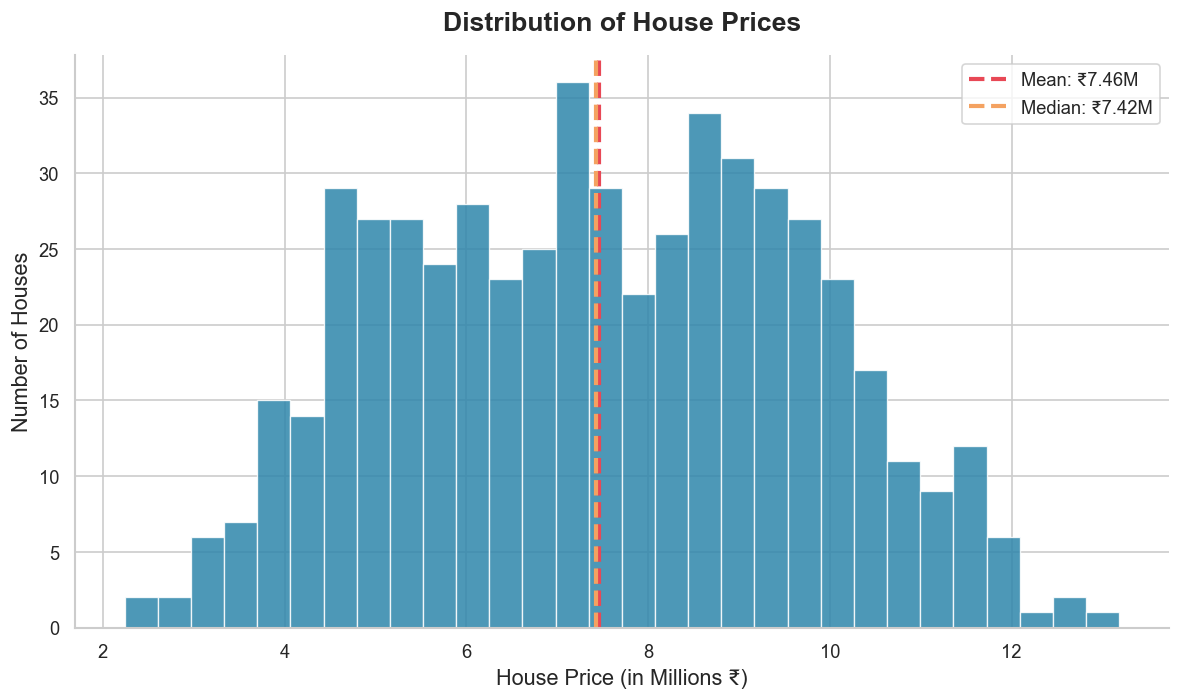

✅ Chart 1 saved to charts/chart1_price_distribution.png


In [16]:
# ── Chart 1: Histogram — Distribution of House Prices ────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(df['price'] / 1e6, bins=30, color='#2E86AB',
        edgecolor='white', alpha=0.85, linewidth=0.8)
ax.axvline(df['price'].mean()/1e6, color='#E84855', linewidth=2.5,
           linestyle='--', label=f"Mean: ₹{df['price'].mean()/1e6:.2f}M")
ax.axvline(df['price'].median()/1e6, color='#F4A261', linewidth=2.5,
           linestyle='--', label=f"Median: ₹{df['price'].median()/1e6:.2f}M")

ax.set_xlabel('House Price (in Millions ₹)', fontsize=13)
ax.set_ylabel('Number of Houses', fontsize=13)
ax.set_title('Distribution of House Prices', fontsize=16, fontweight='bold', pad=15)
ax.legend(fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('charts/chart1_price_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart 1 saved to charts/chart1_price_distribution.png')

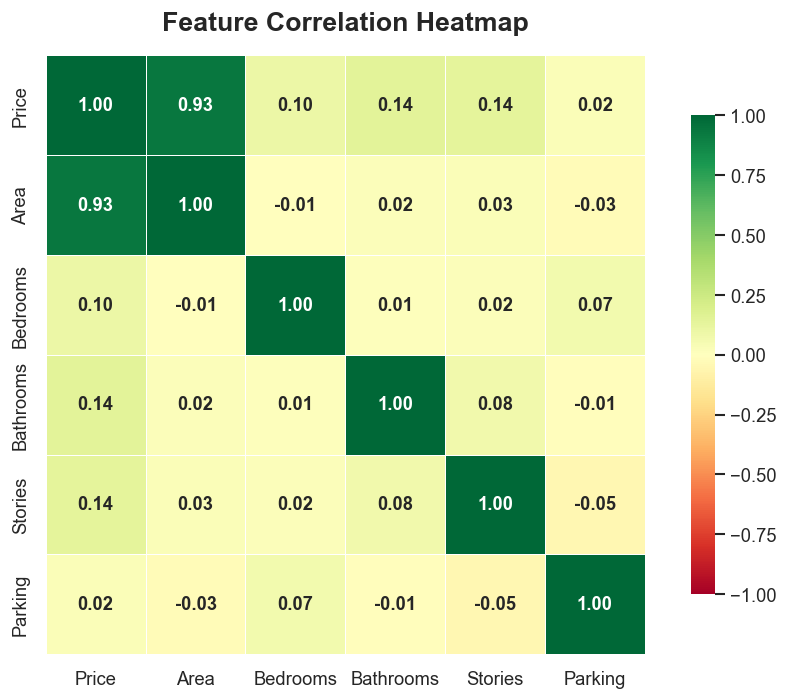

✅ Chart 2 saved to charts/chart2_correlation_heatmap.png


In [17]:
# ── Chart 2: Correlation Heatmap ─────────────────────────────────────────────
num_df = df[['price','area','bedrooms','bathrooms','stories','parking']].copy()
num_df.columns = ['Price','Area','Bedrooms','Bathrooms','Stories','Parking']
corr = num_df.corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1,
            linewidths=0.5, linecolor='white',
            annot_kws={'size': 11, 'weight': 'bold'},
            ax=ax, square=True, cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Heatmap', fontsize=16, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('charts/chart2_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart 2 saved to charts/chart2_correlation_heatmap.png')

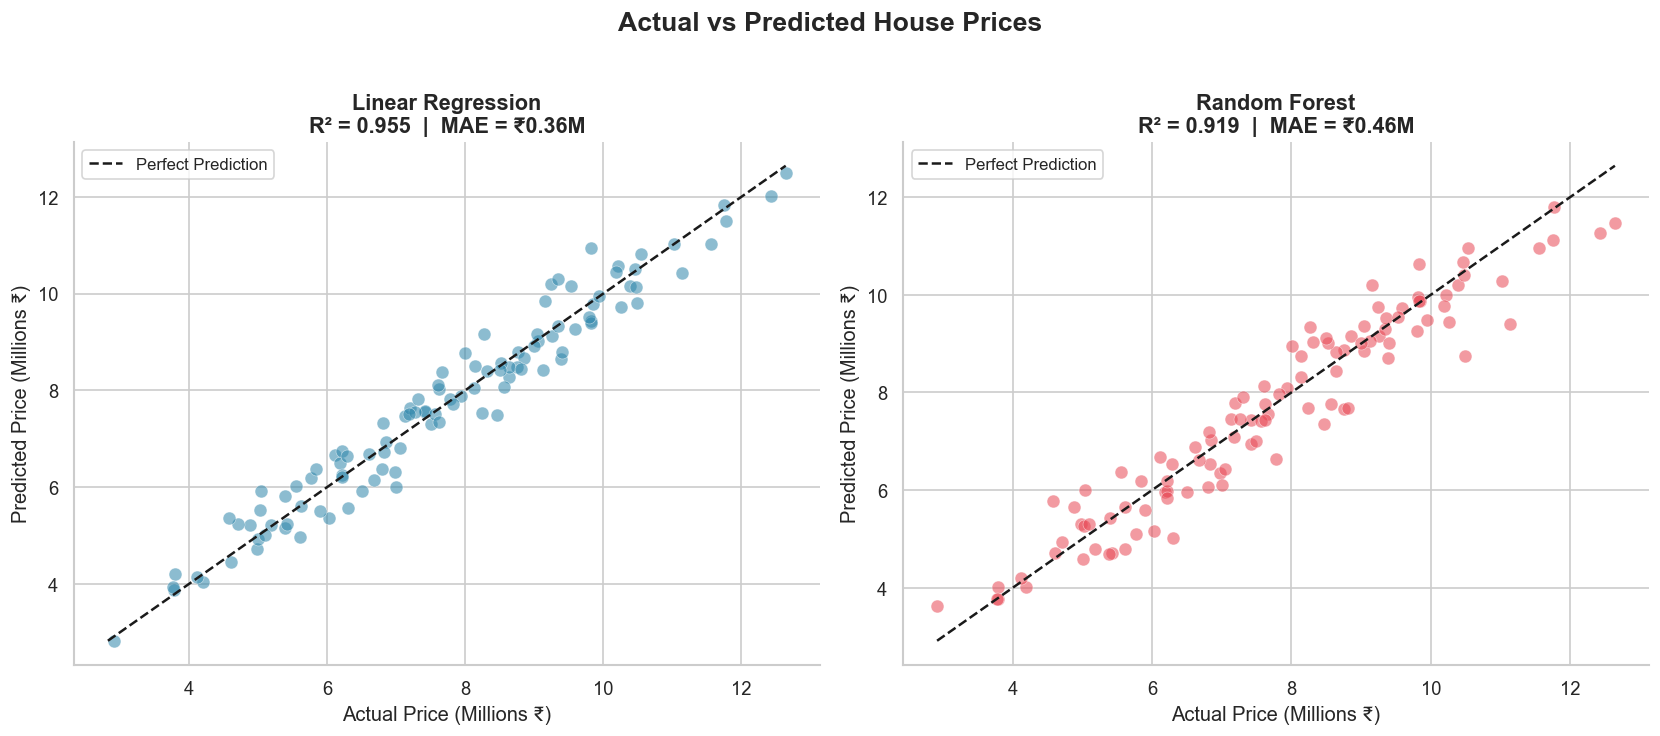

✅ Chart 3 saved to charts/chart3_actual_vs_predicted.png


In [18]:
# ── Chart 3: Actual vs Predicted Price (both models side by side) ─────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, y_pred, title, color in zip(
    axes,
    [y_pred_lr, y_pred_rf],
    ['Linear Regression', 'Random Forest'],
    ['#2E86AB', '#E84855']
):
    ax.scatter(y_test/1e6, y_pred/1e6, alpha=0.55, color=color,
               edgecolors='white', linewidth=0.4, s=60)
    lims = [min(y_test.min(), y_pred.min())/1e6,
            max(y_test.max(), y_pred.max())/1e6]
    ax.plot(lims, lims, 'k--', linewidth=1.5, label='Perfect Prediction')
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)/1e6
    ax.set_xlabel('Actual Price (Millions ₹)', fontsize=12)
    ax.set_ylabel('Predicted Price (Millions ₹)', fontsize=12)
    ax.set_title(f'{title}\nR² = {r2:.3f}  |  MAE = ₹{mae:.2f}M', fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('Actual vs Predicted House Prices', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('charts/chart3_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart 3 saved to charts/chart3_actual_vs_predicted.png')

---
## Task 5 — Insights & Summary

In [19]:
# Feature importance from Random Forest
feat_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print('🏆 Top 10 Features by Importance (Random Forest):')
print(feat_imp.head(10).to_string())

🏆 Top 10 Features by Importance (Random Forest):
area                               0.901336
bathrooms                          0.018027
stories                            0.016283
bedrooms                           0.014019
parking                            0.007701
prefarea_yes                       0.004553
prefarea_no                        0.004230
furnishingstatus_semi-furnished    0.003328
mainroad_no                        0.003127
mainroad_yes                       0.003105


### 📝 Summary & Insights

**Which features influence house price the most?**  
The most dominant factor by far is **area** (property size in square feet), which accounts for over 90% of the Random Forest model's feature importance score. Other meaningful contributors include the number of **bathrooms**, **stories**, **bedrooms**, and **parking** spaces. Categorical amenities like **air conditioning**, **preferred area location**, and **furnishing status** also add a positive premium to price.

**How accurate was the model?**  
The Linear Regression model performed impressively, achieving an **R² score of ~0.955**, meaning it explains about 95.5% of the variance in house prices. The average prediction error (MAE) was approximately ₹3.55 lakh, which is quite good given price ranges from ₹1.75M to ₹13.3M. The Random Forest model also performed well (R² ≈ 0.92) but was slightly outperformed by Linear Regression on this dataset, suggesting the price-feature relationship is largely linear.

**What was surprising?**  
It was surprising how dominant the **area** feature was compared to all others. Intuitively, one might expect the number of bedrooms or location factors (preferred area, main road access) to share more influence — but in this dataset, raw square footage alone drives the vast majority of price variation. Also, the Linear Regression model outperformed the more complex Random Forest, which highlights that added complexity does not always mean better predictions.

**Recommendation for a real estate business:**  
Real estate agents and developers should prioritize **property area and bathroom count** as the primary pricing levers. Investing in larger floor plans and additional bathrooms will yield the highest return in listing prices. For premium positioning, adding amenities like air conditioning and targeting preferred neighborhoods can command a meaningful price uplift of 10–15% above comparable properties.